# Final Results and Analysis

This notebook consolidates all experimental results for the AutoML-based Intrusion Detection System (IDS).

It provides a single place to review:
- Performance metrics and comparison tables
- Visual performance plots (AUC/F1/FPR)
- ROC and Precision–Recall curves
- Confusion matrices
- Model explainability (SHAP)

All results are loaded from saved outputs to ensure reproducibility.

In [3]:
from pathlib import Path
import pandas as pd

# Detect project root reliably (AutoML folder that contains "outputs" and "notebooks")
HERE = Path.cwd()

# If you're running inside AutoML/notebooks, parents[0] is notebooks, parents[1] is AutoML
# We'll search upwards for a folder that contains "outputs"
project_root = None
for p in [HERE] + list(HERE.parents):
    if (p / "outputs").exists():
        project_root = p
        break

if project_root is None:
    raise FileNotFoundError("Could not locate project root (folder containing 'outputs').")

OUTPUTS_DIR = project_root / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PLOTS_DIR   = OUTPUTS_DIR / "plots"

print("Project root:", project_root)
print("Outputs dir:", OUTPUTS_DIR)
print("Metrics dir:", METRICS_DIR)
print("Plots dir:", PLOTS_DIR)

Project root: C:\Users\sohib\Documents\Final Year Project\AutoML
Outputs dir: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs
Metrics dir: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\metrics
Plots dir: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots


In [4]:
from IPython.display import Image, display

def load_csv_safe(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def show_image_safe(path: Path, title: str = None):
    if title:
        print(title)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        # Helpful debug: list close matches from plots folder
        print(f"[Missing image] {path.name}")
        if PLOTS_DIR.exists():
            matches = sorted([p.name for p in PLOTS_DIR.glob(f"*{path.stem.split('_')[0]}*")])[:20]
            print("Some files in outputs/plots (sample):", sorted([p.name for p in PLOTS_DIR.glob("*.png")])[:15])
        raise FileNotFoundError(f"No such file: {path}")

## 1. Results Tables

This section loads the saved experimental result tables from `outputs/metrics/`.
These include:

- **Master results table** (all experiments)
- **Final comparison table** (clean summary used in report)

In [5]:
# folder listing shows both:
# - master_results_table.csv
# - final_comparison_table.csv
# i will load whichever exists and display them cleanly.

master_path = METRICS_DIR / "master_results_table.csv"
final_path  = METRICS_DIR / "final_comparison_table.csv"

master_results = None
final_comparison = None

if master_path.exists():
    master_results = load_csv_safe(master_path)
    print("Loaded:", master_path.name, "| shape:", master_results.shape)
else:
    print("Not found:", master_path)

if final_path.exists():
    final_comparison = load_csv_safe(final_path)
    print("Loaded:", final_path.name, "| shape:", final_comparison.shape)
else:
    print("Not found:", final_path)

# Display
if master_results is not None:
    display(master_results.head(20))

if final_comparison is not None:
    display(final_comparison)

Loaded: master_results_table.csv | shape: (5, 8)
Loaded: final_comparison_table.csv | shape: (5, 7)


,Dataset,Method,AUC,AUCPR,Precision,Recall,F1,FPR
0,UNSW-NB15,Baseline_MI_Selected (CBME Winner),0.984604,0.988656,0.957816,0.916108,0.936498,0.049432
1,UNSW-NB15,PCA (95% variance),0.967981,0.975783,0.933771,0.873026,0.902377,0.075865
2,UNSW-NB15,Autoencoder latent,0.972701,0.979746,0.938657,0.881673,0.909273,0.070595
3,UNSW-NB15,VAE latent,0.966411,0.974010,0.905254,0.893651,0.899415,0.114595
4,NSL-KDD,Baseline_MI_Selected pipeline,0.945074,0.954470,0.868117,0.948414,0.906491,0.190403


,Dataset,Feature_Set,AUC,F1,Precision,Recall,FPR
0,UNSW-NB15,Baseline_MI_Selected (CBME Winner),0.984604,0.936498,0.957816,0.916108,0.049432
1,UNSW-NB15,Autoencoder Latent Features,0.972701,0.909273,0.938657,0.881673,0.070595
2,UNSW-NB15,PCA Latent Features,0.967981,0.902377,0.933771,0.873026,0.075865
3,UNSW-NB15,VAE Latent Features,0.966411,0.899415,0.905254,0.893651,0.114595
4,NSL-KDD,Baseline_MI_Selected Pipeline,0.945074,0.906491,0.868117,0.948414,0.190403


## 2. Feature Engineering Comparison (UNSW-NB15)

The following plots compare model performance across feature representations:
- Baseline (Mutual Information selected)
- PCA (95% variance)
- Autoencoder latent features
- VAE latent features

AUC Comparison (UNSW-NB15)


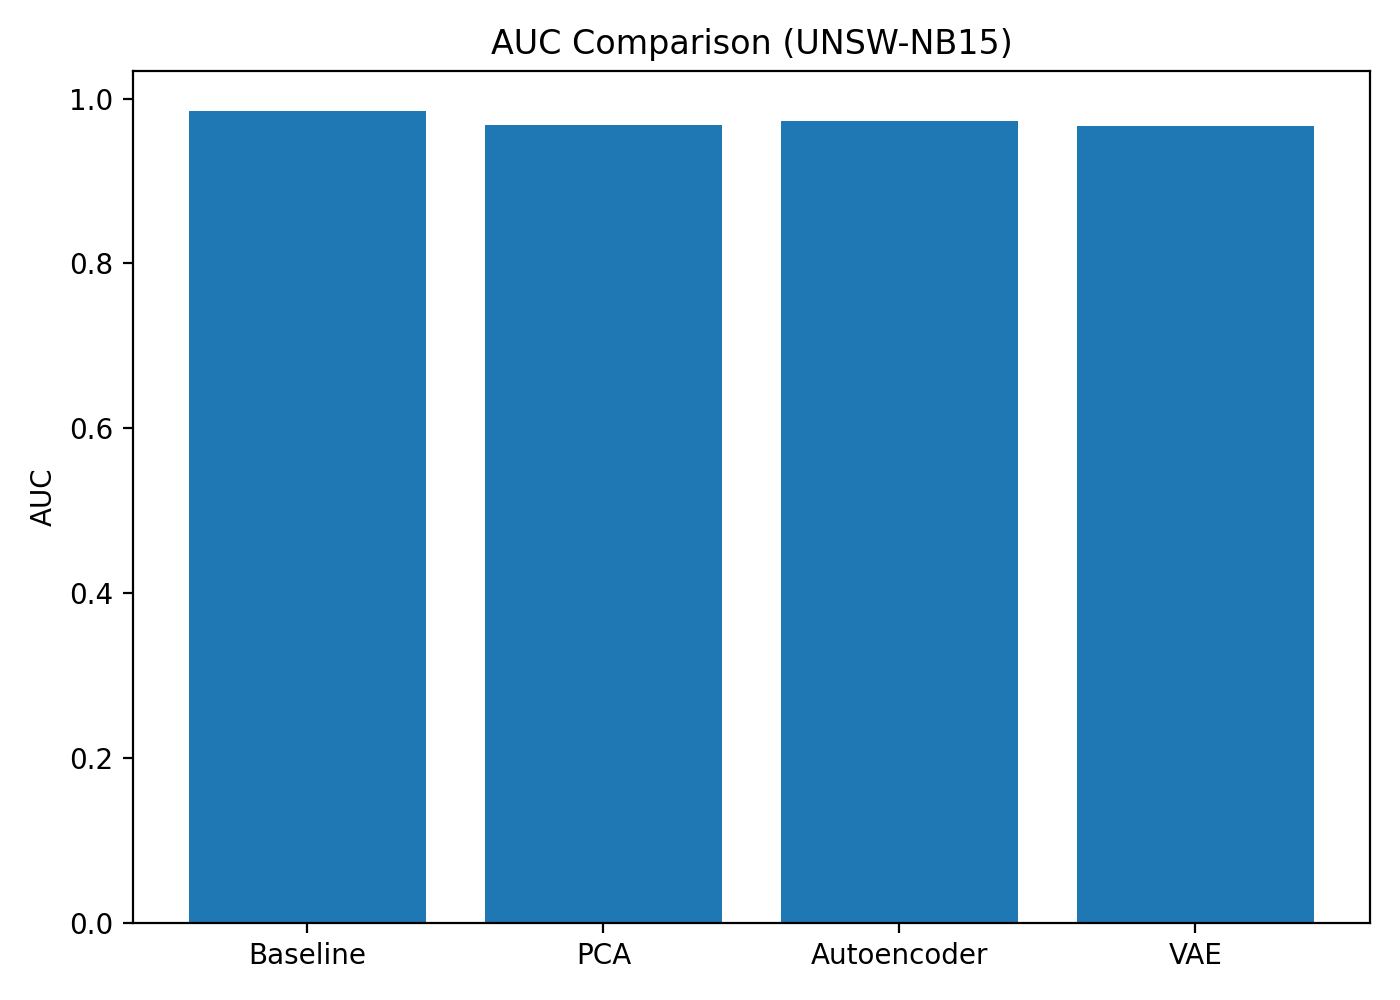

F1 Comparison (UNSW-NB15)


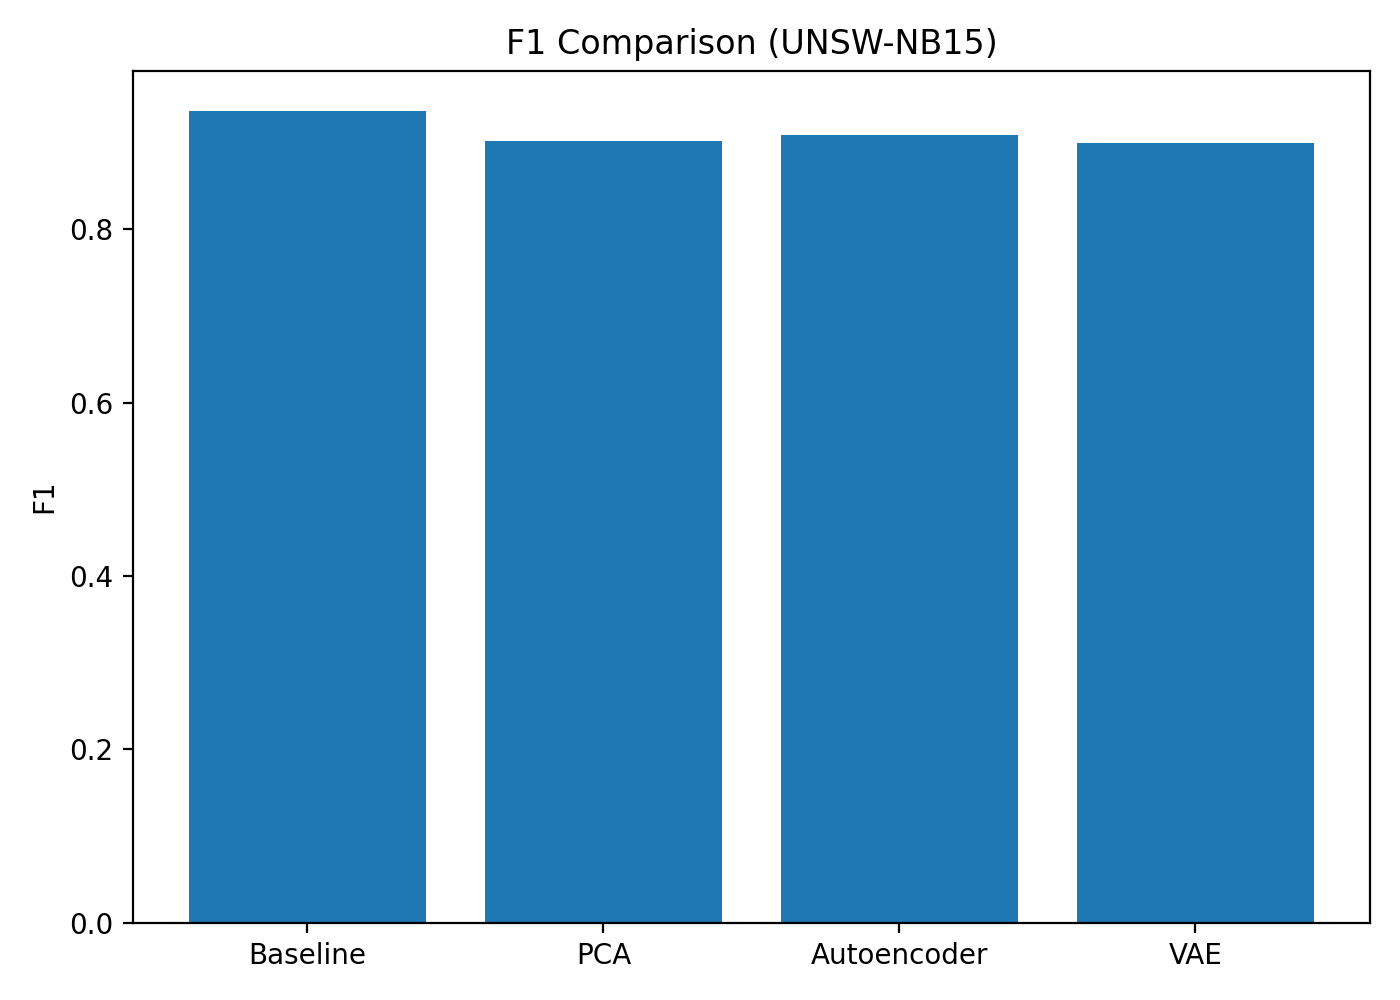

FPR Comparison (UNSW-NB15)


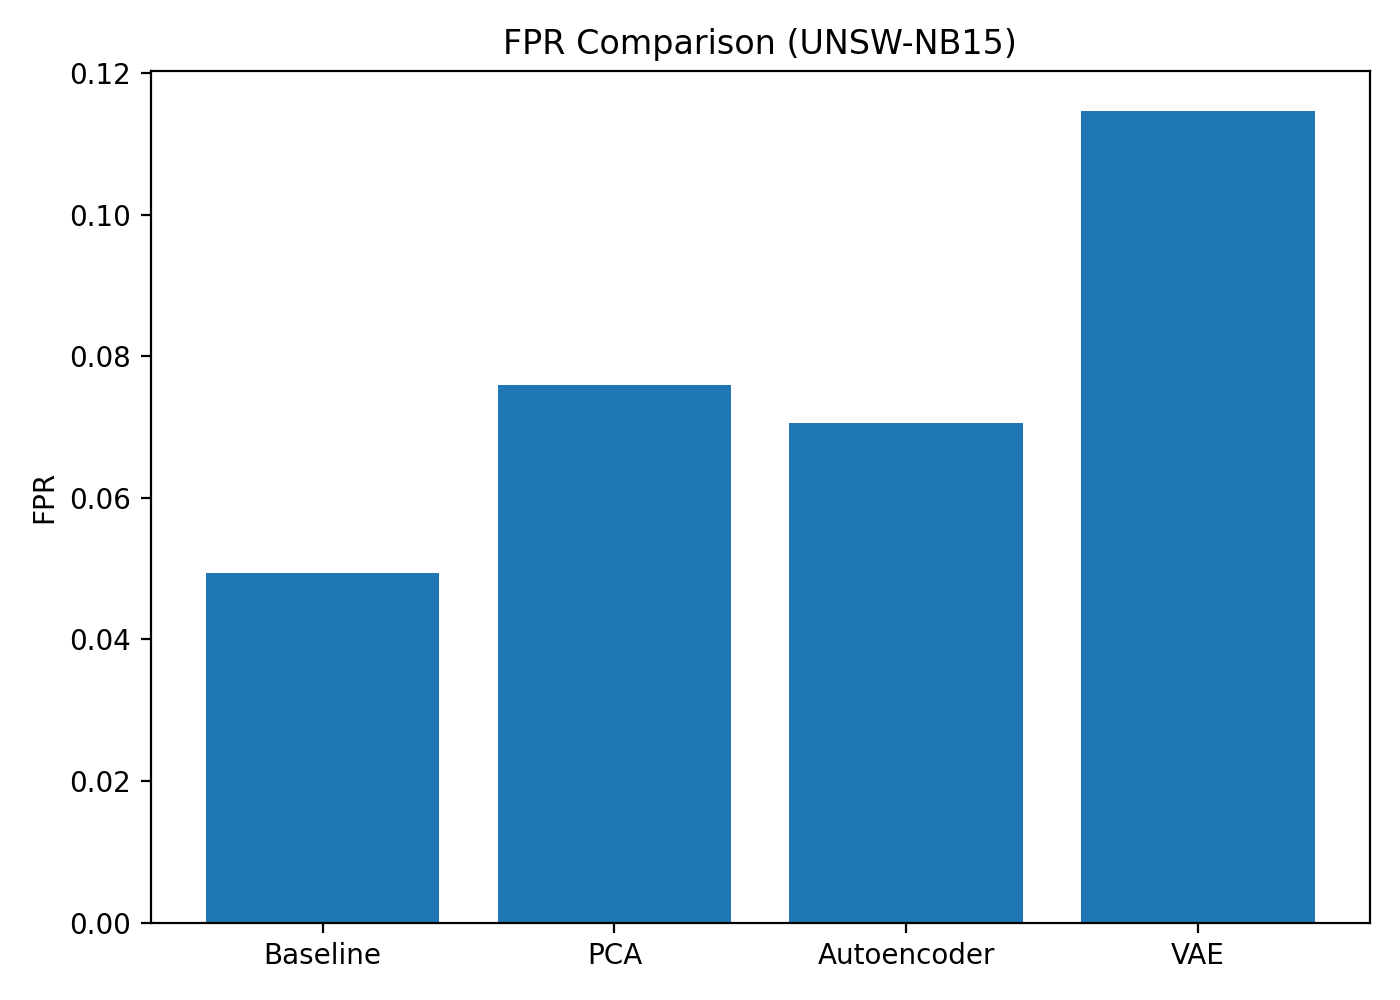

In [6]:
show_image_safe(PLOTS_DIR / "perf_auc_unsw.png", "AUC Comparison (UNSW-NB15)")
show_image_safe(PLOTS_DIR / "perf_f1_unsw.png",  "F1 Comparison (UNSW-NB15)")
show_image_safe(PLOTS_DIR / "perf_fpr_unsw.png", "FPR Comparison (UNSW-NB15)")

## 3. ROC and Precision–Recall Curves

ROC and PR curves provide insight into classifier behaviour across thresholds.
These plots compare performance across feature engineering methods.

ROC Curves (UNSW-NB15)


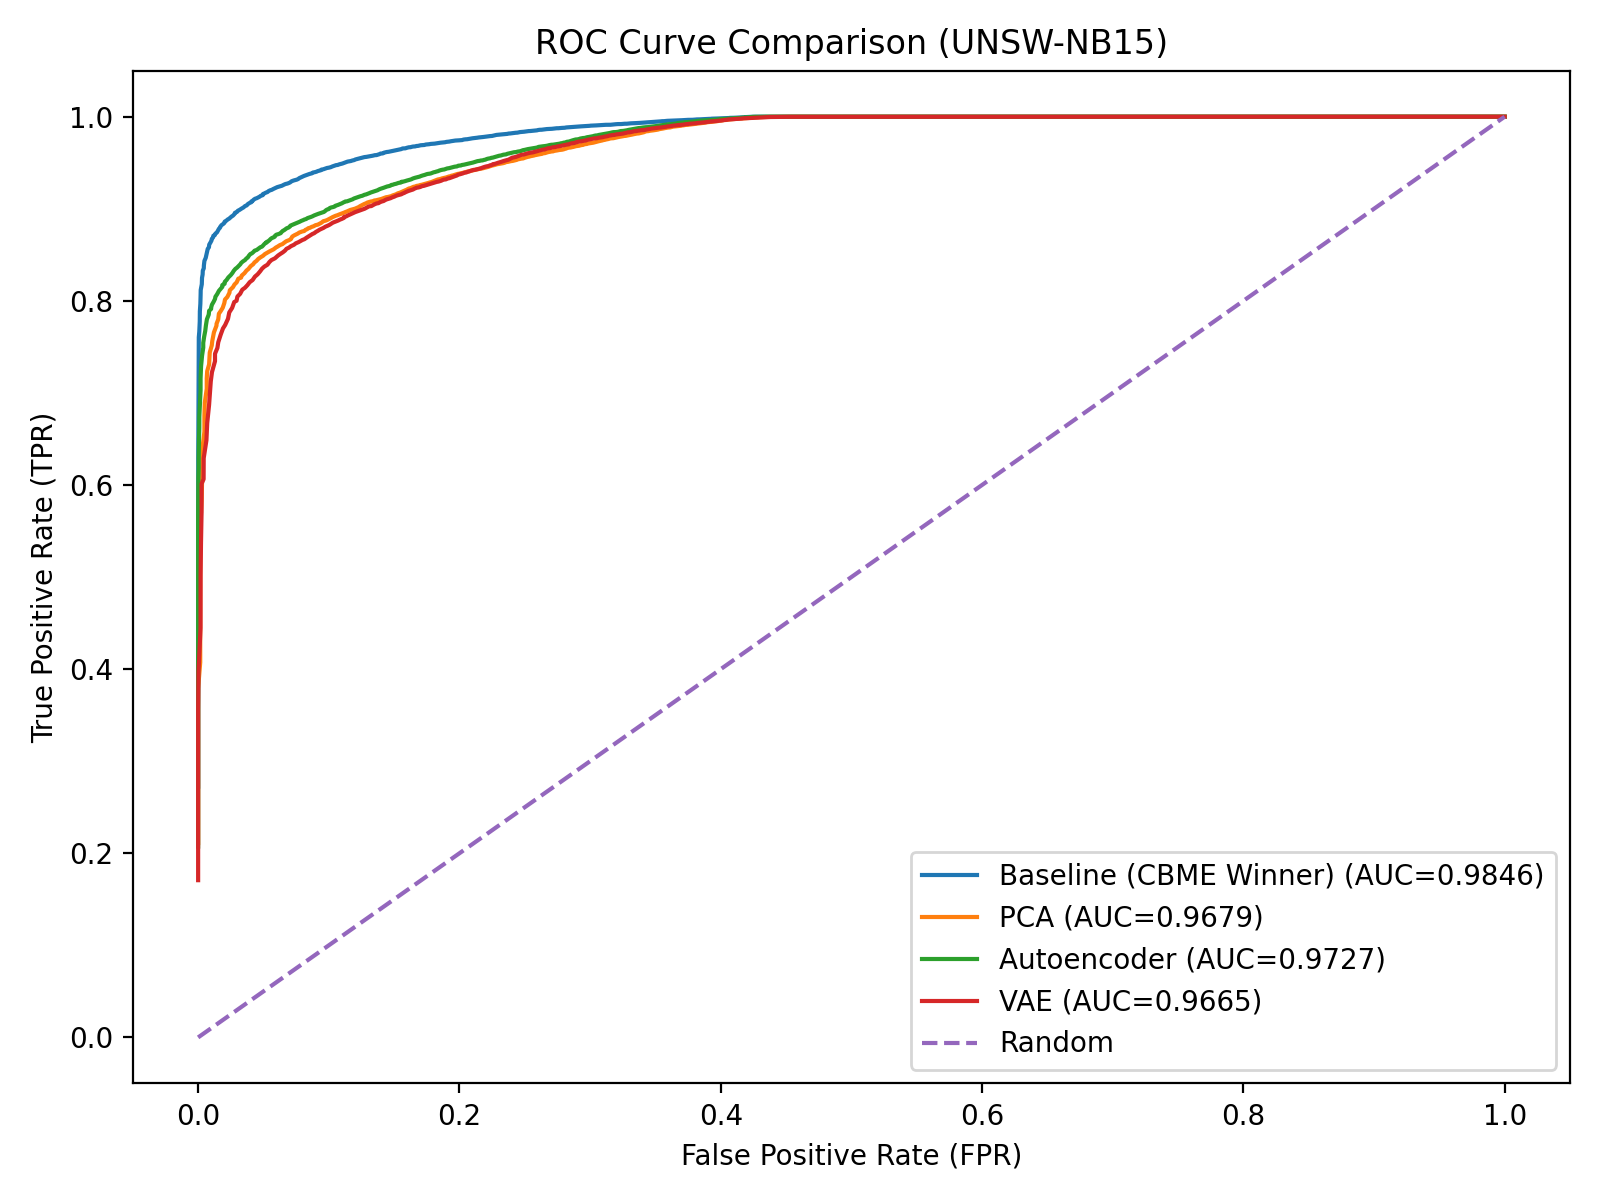

Precision–Recall Curves (UNSW-NB15)


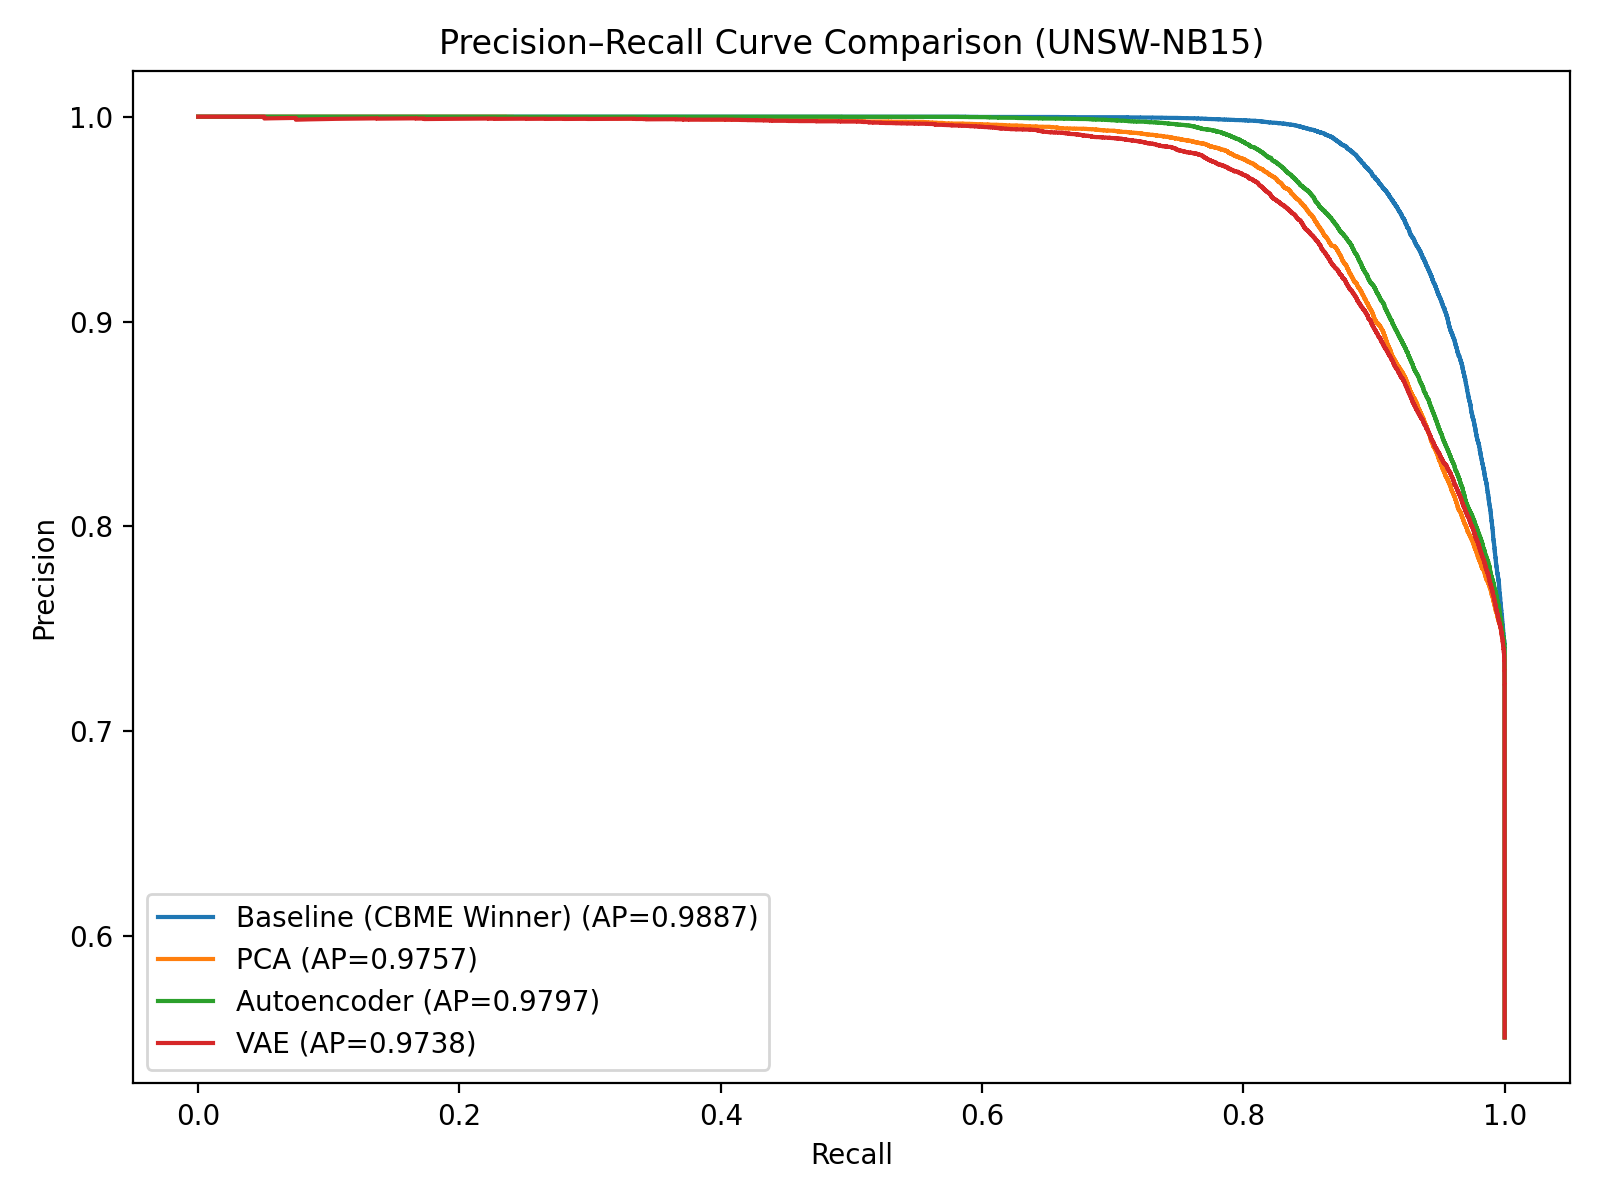

In [7]:
show_image_safe(PLOTS_DIR / "roc_unsw_comparison.png", "ROC Curves (UNSW-NB15)")
show_image_safe(PLOTS_DIR / "pr_unsw_comparison.png",  "Precision–Recall Curves (UNSW-NB15)")

## 4. Confusion Matrix Analysis

Confusion matrices show True Positives, False Positives, True Negatives and False Negatives.
They are useful to highlight False Positive Rate (FPR) and missed attacks.

Confusion Matrix (UNSW-NB15)


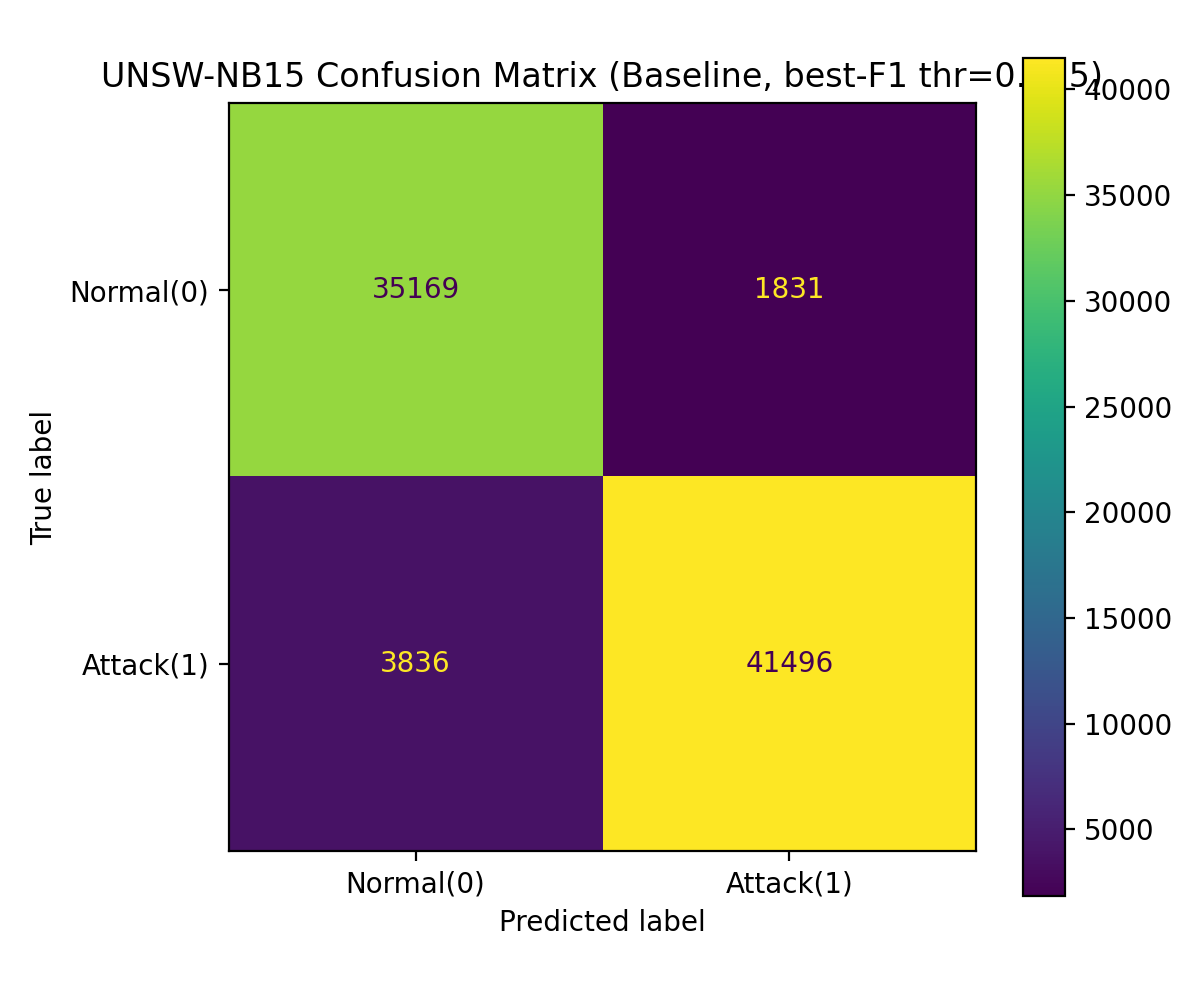

Confusion Matrix (NSL-KDD)


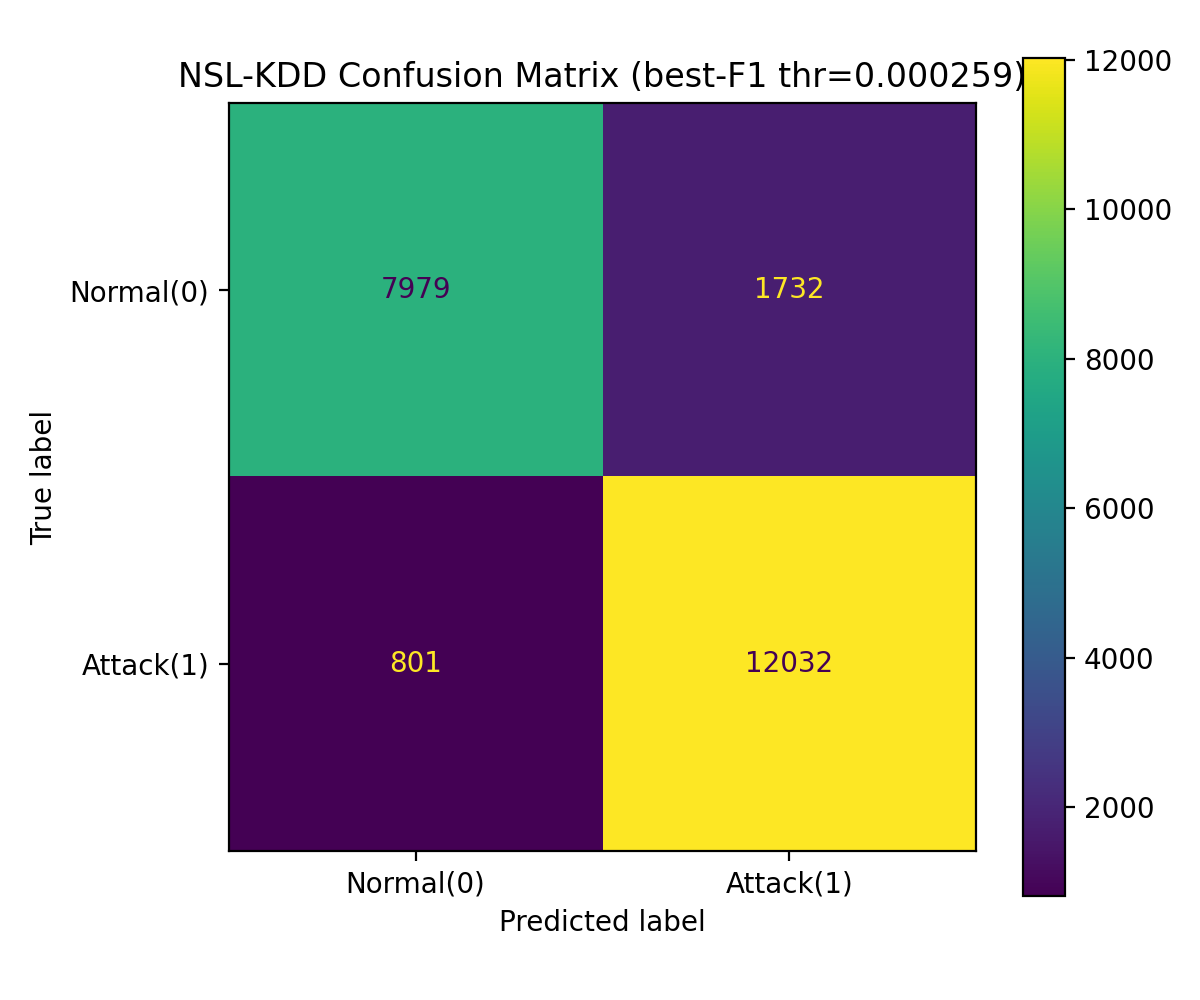

In [8]:
show_image_safe(PLOTS_DIR / "confusion_unsw_baseline.png", "Confusion Matrix (UNSW-NB15)")
show_image_safe(PLOTS_DIR / "confusion_kdd_baseline.png",  "Confusion Matrix (NSL-KDD)")

## 5. AutoML Leaderboards and Model Search

This section summarises which model families were explored by AutoML and which performed best.

AutoML Leaderboard Top-10 (UNSW)


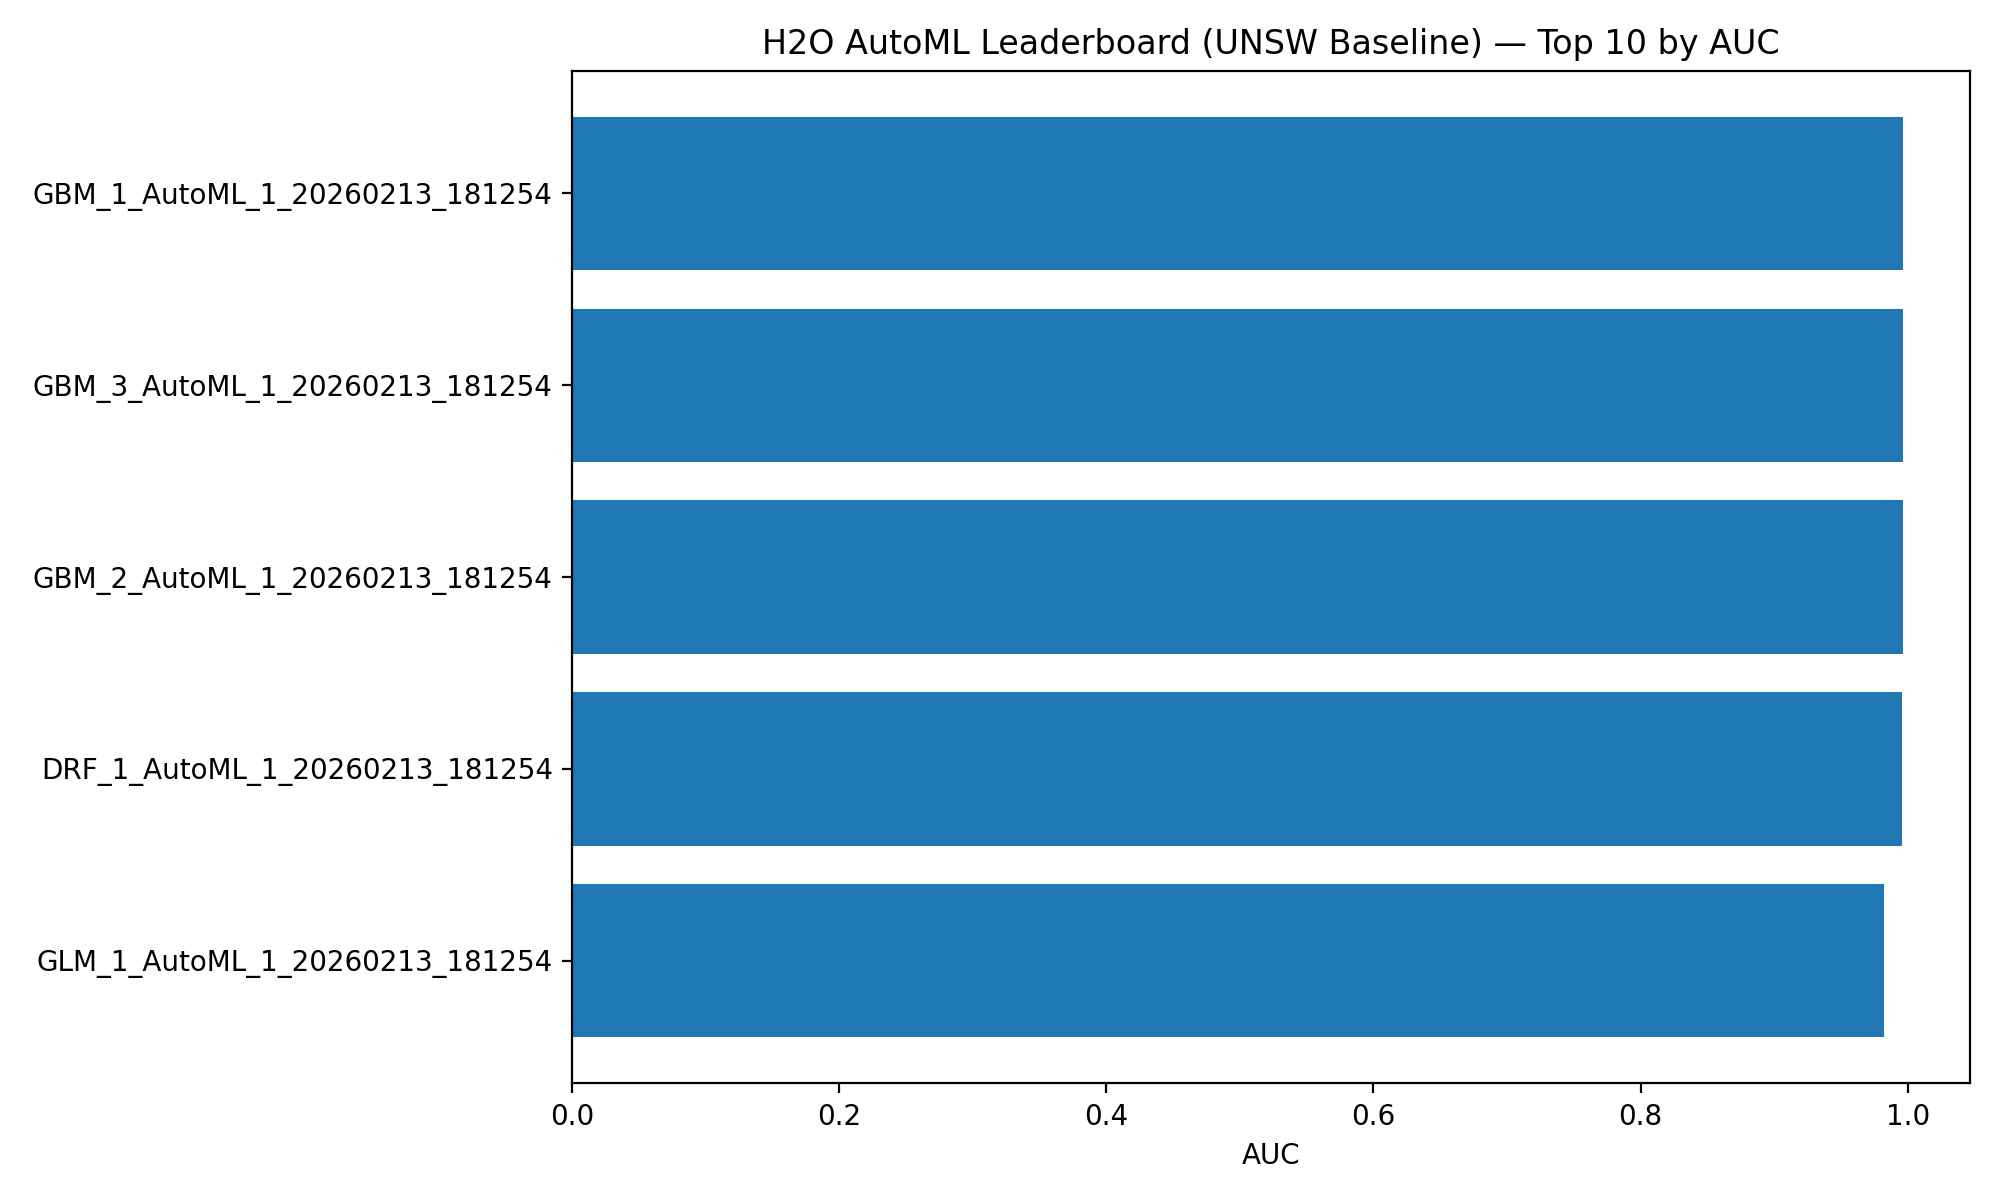

AutoML Model Type Counts (UNSW)


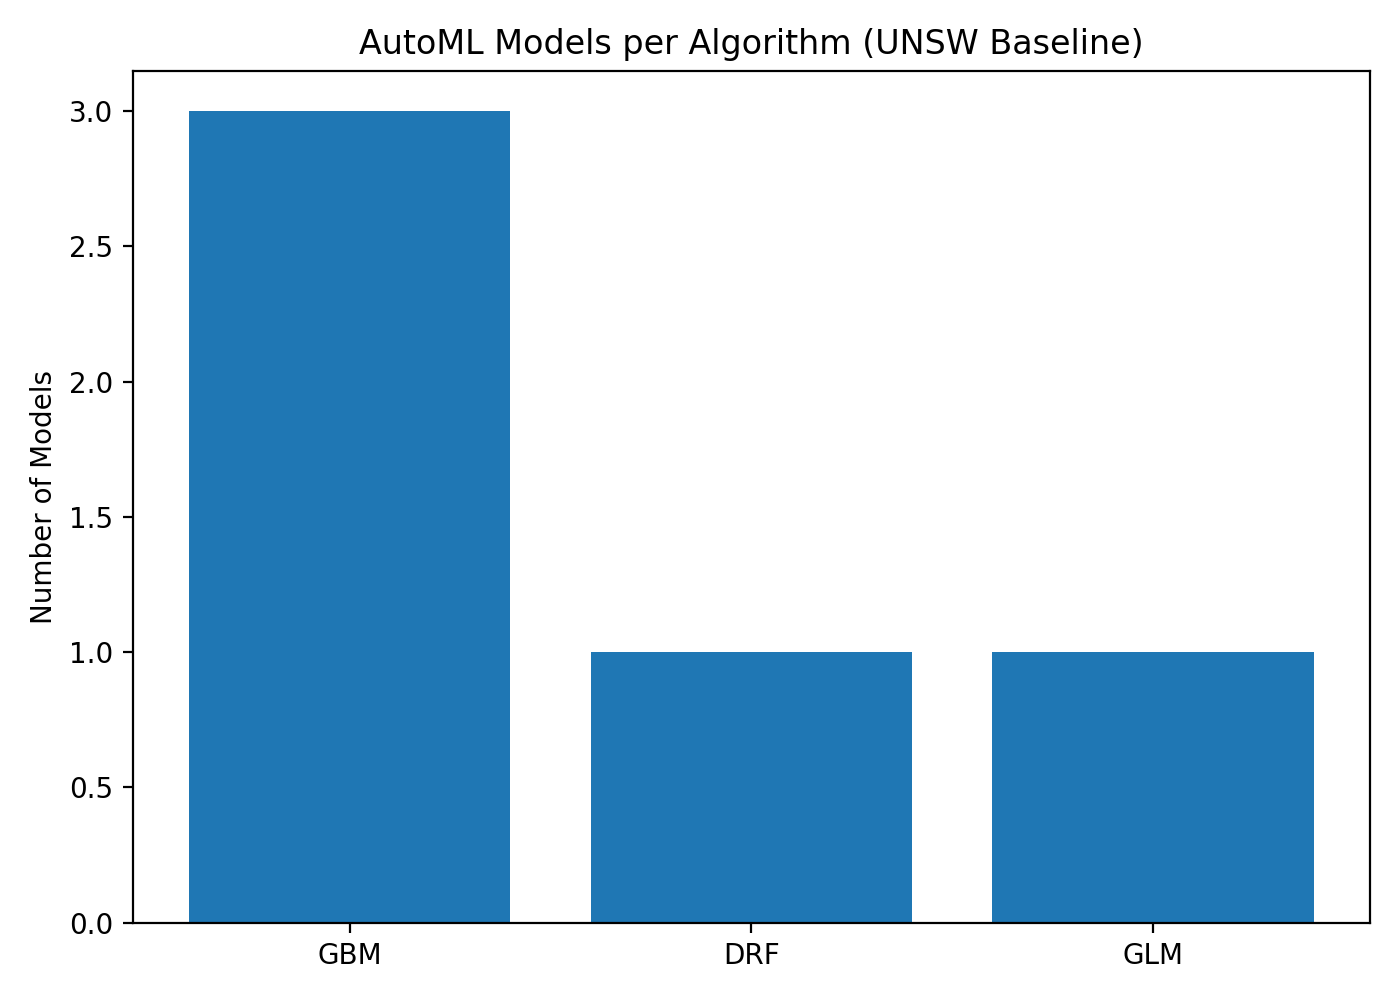

AutoML Leaderboard Top-10 (NSL-KDD)


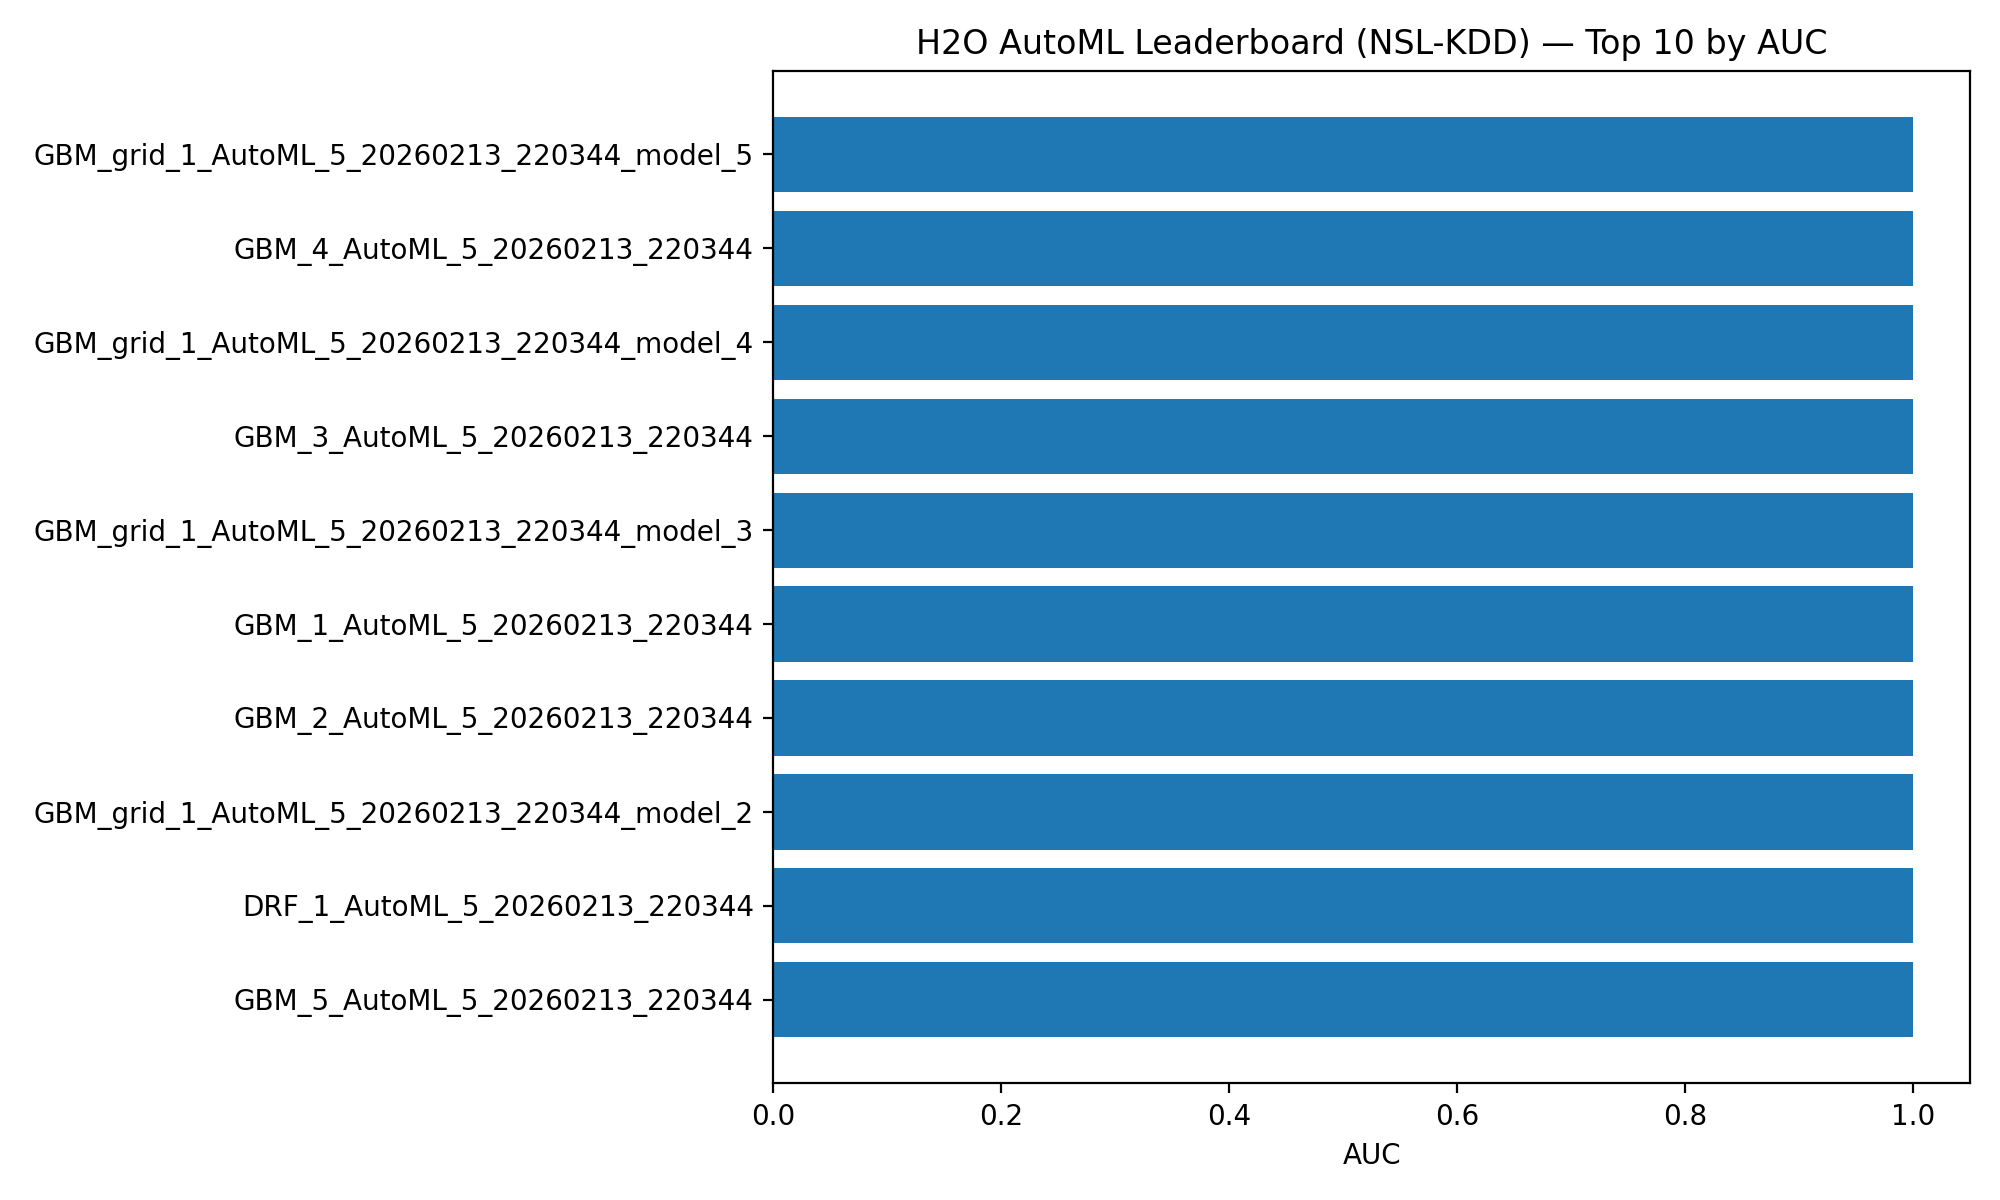

AutoML Model Type Counts (NSL-KDD)


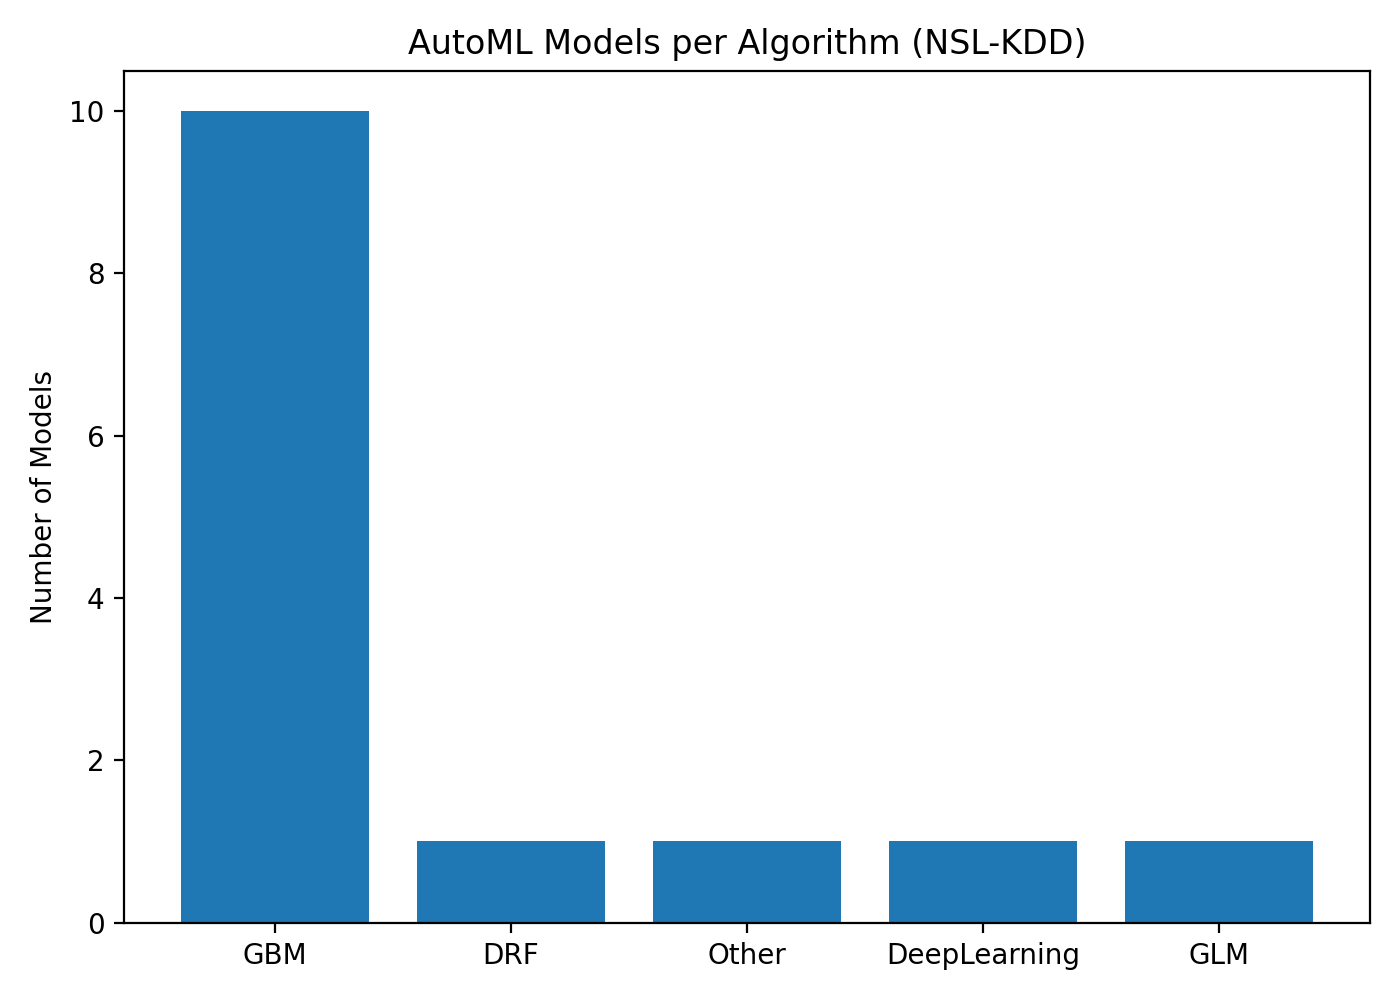

In [9]:
show_image_safe(PLOTS_DIR / "automl_leaderboard_unsw_top10.png", "AutoML Leaderboard Top-10 (UNSW)")
show_image_safe(PLOTS_DIR / "automl_model_counts_unsw.png",      "AutoML Model Type Counts (UNSW)")

show_image_safe(PLOTS_DIR / "automl_leaderboard_kdd_top10.png",  "AutoML Leaderboard Top-10 (NSL-KDD)")
show_image_safe(PLOTS_DIR / "automl_model_counts_kdd.png",       "AutoML Model Type Counts (NSL-KDD)")

## 6. Model Explainability (SHAP)

SHAP was used to interpret the AutoML-selected model by ranking the most influential features.
This supports trust and transparency in the IDS decision-making process.

SHAP Feature Importance (H2O AutoML Model)


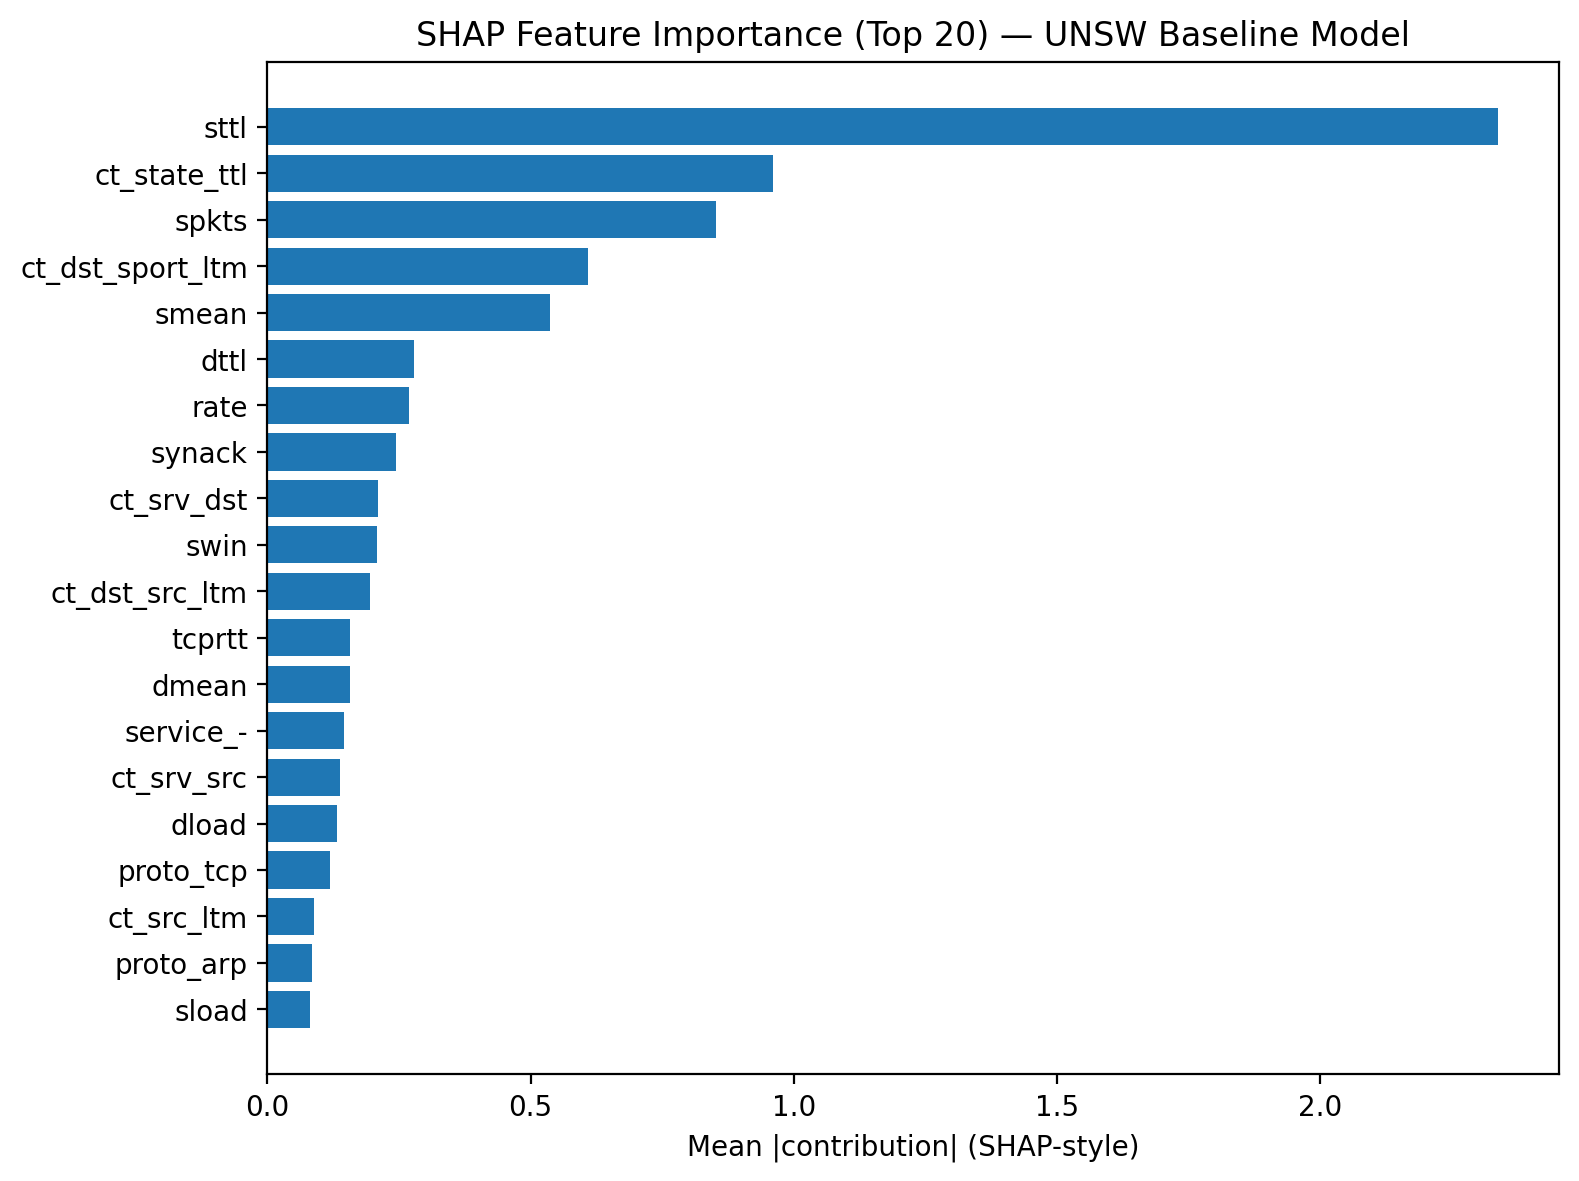

In [10]:
show_image_safe(PLOTS_DIR / "shap_importance_h2o.png", "SHAP Feature Importance (H2O AutoML Model)")

## 7. Final Summary (Key Results)

This table gives a short summary of the best-performing configuration and its key metrics,
including cross-dataset validation.

In [11]:
summary_rows = []

# Try to pick best row automatically from final_comparison or master_results
if final_comparison is not None and len(final_comparison) > 0:
    df = final_comparison.copy()
    # Try common column names
    auc_col = "AUC" if "AUC" in df.columns else None
    if auc_col:
        best = df.sort_values(auc_col, ascending=False).iloc[0].to_dict()
        summary_rows.append(("Best (Final Comparison)", best))
elif master_results is not None and len(master_results) > 0:
    df = master_results.copy()
    auc_col = "AUC" if "AUC" in df.columns else None
    if auc_col:
        best = df.sort_values(auc_col, ascending=False).iloc[0].to_dict()
        summary_rows.append(("Best (Master Results)", best))

summary_rows[:1]

[('Best (Final Comparison)',
  {'Dataset': 'UNSW-NB15',
   'Feature_Set': 'Baseline_MI_Selected (CBME Winner)',
   'AUC': 0.9846041991099898,
   'F1': 0.9364979140827602,
   'Precision': 0.9578163199409568,
   'Recall': 0.9161078267007852,
   'FPR': 0.0494324324324324})]

## 8. Efficiency and Energy Considerations

This section reports computational efficiency results to complement predictive performance:

- **Training time** (if recorded in run configuration logs)
- **Inference latency** (time to score batches of traffic records)
- **Model size** (storage footprint)
- **Approximate energy and carbon** (based on runtime and power assumptions)

These results support discussion of practical deployment for an IDS (performance vs cost).

In [12]:
import json, time
import numpy as np
import pandas as pd
from pathlib import Path

import h2o
from h2o.estimators import H2OGradientBoostingEstimator  # not required, but ok

def read_json_safe(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

def file_size_mb(path: Path) -> float:
    return round(path.stat().st_size / (1024**2), 3) if path.exists() else np.nan

def list_model_dirs(models_saved_dir: Path):
    # model dirs are usually folders like GBM_... plus autoencoder/vae folders
    if not models_saved_dir.exists():
        return []
    return [p for p in models_saved_dir.iterdir() if p.is_dir()]

print("Ready.")

Ready.


In [13]:
RUN_CONFIG = METRICS_DIR / "run_config.json"
BAL_INFO   = METRICS_DIR / "balancing_info.json"
KDD_BAL    = METRICS_DIR / "kdd_balancing_info.json"

run_config = read_json_safe(RUN_CONFIG)
bal_info = read_json_safe(BAL_INFO)
kdd_bal_info = read_json_safe(KDD_BAL)

print("run_config.json exists:", RUN_CONFIG.exists())
print("balancing_info.json exists:", BAL_INFO.exists())
print("kdd_balancing_info.json exists:", KDD_BAL.exists())

if run_config:
    print("run_config keys:", list(run_config.keys())[:25])

run_config.json exists: True
balancing_info.json exists: True
kdd_balancing_info.json exists: True
run_config keys: ['seed', 'train_path', 'test_path', 'target', 'leakage_cols_removed', 'train_shape', 'test_shape', 'x_train_shape', 'x_test_shape']


### 8.1 Load best model + evaluation frames

We use the saved best model and saved test frames to measure **inference time**, model footprint,
and to support reproducible comparisons.

In [14]:
# ---  Start/Connect H2O + load best model from outputs/models_saved ---

from pathlib import Path
import json
import h2o

# 1) Ensure H2O is running
try:
    h2o.cluster().show_status()
except Exception:
    h2o.init()

# 2) Paths (assumes OUTPUTS_DIR and METRICS_DIR already defined earlier)
MODELS_SAVED_DIR = OUTPUTS_DIR / "models_saved"
CBME_WINNER = METRICS_DIR / "cbme_winner.json"

print("MODELS_SAVED_DIR:", MODELS_SAVED_DIR)
print("Exists:", MODELS_SAVED_DIR.exists())

# 3) Helper: list saved models (files OR directories), exclude known non-H2O folders
def list_saved_h2o_models(models_saved_dir: Path):
    if not models_saved_dir.exists():
        return []

    items = []
    for p in models_saved_dir.iterdir():
        # ignore folders that are not H2O models
        if p.name.lower() in ["autoencoder", "vae"]:
            continue

        # H2O saved model may be a file OR a directory
        if p.is_file() or p.is_dir():
            items.append(p)

    return sorted(items, key=lambda x: x.name)

# 4) Try to read winner from cbme_winner.json
best_model_id = None
if CBME_WINNER.exists():
    with open(CBME_WINNER, "r", encoding="utf-8") as f:
        winner = json.load(f)

    # try common keys
    for k in ["model_id", "winner_model", "best_model_id", "winner", "model"]:
        if k in winner and isinstance(winner[k], str) and winner[k].strip():
            best_model_id = winner[k].strip()
            break

print("Winner model id from cbme_winner.json:", best_model_id)

# 5) If winner id not found, pick the first GBM_* item in models_saved
saved_items = list_saved_h2o_models(MODELS_SAVED_DIR)

print("\nSaved items found in models_saved (first 20):")
for p in saved_items[:20]:
    kind = "DIR" if p.is_dir() else "FILE"
    print(" -", kind, p.name)

if best_model_id is None:
    gbm_candidates = [p for p in saved_items if p.name.startswith("GBM_") or "GBM" in p.name]
    if not gbm_candidates:
        raise FileNotFoundError(
            f"No GBM models found in {MODELS_SAVED_DIR}. "
            f"Check folder contents printed above."
        )
    best_model_path = gbm_candidates[0]
else:
    best_model_path = MODELS_SAVED_DIR / best_model_id
    if not best_model_path.exists():
        # fallback: match by prefix if exact path doesn't exist
        matches = [p for p in saved_items if p.name == best_model_id or p.name.startswith(best_model_id)]
        if matches:
            best_model_path = matches[0]
        else:
            raise FileNotFoundError(f"Winner model '{best_model_id}' not found inside {MODELS_SAVED_DIR}")

print("\nSelected best model path:", best_model_path)

# 6) Load model (works for file OR folder)
model = h2o.load_model(str(best_model_path))
print("✅ Loaded H2O model:", model.model_id)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 23.0.1+11-39, mixed mode, sharing)
  Starting server from C:\Users\sohib\anaconda3\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\sohib\AppData\Local\Temp\tmpkcdi58jd
  JVM stdout: C:\Users\sohib\AppData\Local\Temp\tmpkcdi58jd\h2o_sohib_started_from_python.out
  JVM stderr: C:\Users\sohib\AppData\Local\Temp\tmpkcdi58jd\h2o_sohib_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,3 months and 10 days
H2O_cluster_name:,H2O_from_python_sohib_l3wf4v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.908 Gb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"


MODELS_SAVED_DIR: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved
Exists: True
Winner model id from cbme_winner.json: None

Saved items found in models_saved (first 20):
 - FILE GBM_1_AutoML_1_20260213_181254
 - FILE GBM_4_AutoML_3_20260213_200153
 - FILE GBM_grid_1_AutoML_2_20260213_185958_model_3
 - FILE GBM_grid_1_AutoML_4_20260213_205118_model_3
 - FILE GBM_grid_1_AutoML_5_20260213_220344_model_5

Selected best model path: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\GBM_1_AutoML_1_20260213_181254
✅ Loaded H2O model: GBM_1_AutoML_1_20260213_181254


In [15]:
import pandas as pd

TEST_FRAMES_DIR = OUTPUTS_DIR / "test_frames"

test_files = {
    "UNSW_baseline": TEST_FRAMES_DIR / "test_baseline.parquet",
    "NSL_KDD": TEST_FRAMES_DIR / "test_kdd.parquet",
}

for k, p in test_files.items():
    print(k, "exists:", p.exists(), "|", p)

# load
frames_pd = {}
for name, path in test_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing test frame: {path}")
    frames_pd[name] = pd.read_parquet(path)

# infer label column (try common names)
def guess_label_col(df: pd.DataFrame):
    for c in ["label", "Label", "target", "Target", "class", "Class", "y", "Y"]:
        if c in df.columns:
            return c
    return df.columns[-1]  # fallback (not ideal, but safe)

LABEL_COL = guess_label_col(frames_pd["UNSW_baseline"])
print("Guessed LABEL_COL:", LABEL_COL)

# convert to H2OFrames
frames_h2o = {}
for name, df in frames_pd.items():
    frames_h2o[name] = h2o.H2OFrame(df)
    # ensure label is categorical for binomial if needed
    if LABEL_COL in frames_h2o[name].columns:
        frames_h2o[name][LABEL_COL] = frames_h2o[name][LABEL_COL].asfactor()

print("Loaded frames into H2O:", list(frames_h2o.keys()))

UNSW_baseline exists: True | C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\test_frames\test_baseline.parquet
NSL_KDD exists: True | C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\test_frames\test_kdd.parquet
Guessed LABEL_COL: label
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Loaded frames into H2O: ['UNSW_baseline', 'NSL_KDD']


### 8.2 Inference latency (scoring time)

We measure **prediction time** on the saved test frames.
We report:
- time to score N rows
- throughput (rows/sec)

This supports deployability discussion for real-time IDS pipelines.

In [16]:
def time_inference(h2_frame, n_rows=50000, repeats=3, warmup=True):
    # sample up to n_rows
    n = min(n_rows, h2_frame.nrows)
    hf = h2_frame[:n, :]

    if warmup:
        _ = model.predict(hf)  # warmup
        h2o.cluster().show_status()

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = model.predict(hf)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    avg = float(np.mean(times))
    std = float(np.std(times))
    rps = n / avg if avg > 0 else np.nan
    return {"rows_scored": n, "avg_sec": avg, "std_sec": std, "rows_per_sec": rps}

latency_results = []
for name, hf in frames_h2o.items():
    m = time_inference(hf, n_rows=50000, repeats=3, warmup=True)
    latency_results.append({"Dataset": name, **m})

latency_df = pd.DataFrame(latency_results)
latency_df

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


H2O_cluster_uptime:,18 secs
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,3 months and 10 days
H2O_cluster_name:,H2O_from_python_sohib_l3wf4v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.846 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'sbytes': substituting in a column of NaN
  warnings.warn(w)
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'smean': substituting in a column of NaN
  warnings.warn(w)
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'sttl': substituting in a column of NaN
  warnings.warn(w)
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'sload': substituting in a column of NaN
  warnings.warn(w)
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'rate': substituting in a column of NaN
  warnings.warn(w)
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'dbytes': substituting 

H2O_cluster_uptime:,21 secs
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,3 months and 10 days
H2O_cluster_name:,H2O_from_python_sohib_l3wf4v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.846 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


,Dataset,rows_scored,avg_sec,std_sec,rows_per_sec
0,UNSW_baseline,50000,0.665952,0.114789,75080.478766
1,NSL_KDD,22544,0.470861,0.001570,47878.238402


### 8.3 Storage footprint

We measure the on-disk size of:
- the chosen best model (H2O model folder)
- preprocessing artifacts (joblib)
- feature extractor artifacts (e.g., PCA)

This supports discussion of deployment constraints.

In [17]:
# --- Compute artifact sizes safely (handles best_model_id=None) ---

from pathlib import Path
import os
import pandas as pd

MODELS_DIR = OUTPUTS_DIR / "models"
MODELS_SAVED_DIR = OUTPUTS_DIR / "models_saved"

# 1) Determine best model id safely
# Prefer the actually loaded model id (most reliable)
best_model_id = None
try:
    best_model_id = model.model_id
except Exception:
    pass

# Fallback: pick a GBM-like item from models_saved
if not best_model_id:
    candidates = []
    if MODELS_SAVED_DIR.exists():
        for p in MODELS_SAVED_DIR.iterdir():
            if p.name.lower() in ["autoencoder", "vae"]:
                continue
            if p.name.startswith("GBM_") or "GBM" in p.name:
                candidates.append(p.name)
    best_model_id = sorted(candidates)[0] if candidates else None

print("best_model_id used for artifacts:", best_model_id)

# 2) Build artifact file map (only include paths that exist)
artifact_files = {}

if best_model_id:
    artifact_files["best_h2o_model"] = MODELS_SAVED_DIR / best_model_id

# these are your pipeline artifacts in outputs/models/
artifact_files["preprocessor.joblib"] = MODELS_DIR / "preprocessor.joblib"
artifact_files["kdd_preprocessor.joblib"] = MODELS_DIR / "kdd_preprocessor.joblib"
artifact_files["pca_95.joblib"] = MODELS_DIR / "pca_95.joblib"

# 3) Size helpers
def dir_size_bytes(path: Path) -> int:
    total = 0
    for root, _, files in os.walk(path):
        for fn in files:
            fp = Path(root) / fn
            try:
                total += fp.stat().st_size
            except OSError:
                pass
    return total

def path_size_mb(path: Path) -> float:
    if not path.exists():
        return float("nan")
    if path.is_dir():
        return dir_size_bytes(path) / (1024**2)
    return path.stat().st_size / (1024**2)

# 4) Create table
rows = []
for label, p in artifact_files.items():
    rows.append({
        "artifact": label,
        "path": str(p),
        "exists": p.exists(),
        "type": "dir" if p.exists() and p.is_dir() else ("file" if p.exists() else "missing"),
        "size_mb": round(path_size_mb(p), 3) if p.exists() else None
    })

sizes_df = pd.DataFrame(rows).sort_values(["exists", "artifact"], ascending=[False, True])
sizes_df

best_model_id used for artifacts: GBM_1_AutoML_1_20260213_181254


,artifact,path,exists,type,size_mb
0,best_h2o_model,C:\Users\sohib\Documents\Final Year Project\Au...,True,file,2.127
2,kdd_preprocessor.joblib,C:\Users\sohib\Documents\Final Year Project\Au...,True,file,0.006
3,pca_95.joblib,C:\Users\sohib\Documents\Final Year Project\Au...,True,file,0.035
1,preprocessor.joblib,C:\Users\sohib\Documents\Final Year Project\Au...,True,file,0.006


Reproducibility artifacts (storage footprint).
The final H2O model and preprocessing components were exported to disk to enable reproducible scoring without retraining. The best model (GBM_1_AutoML_1_20260213_181254) is ~2.13 MB, while preprocessing artefacts (scalers/encoders and PCA object) are lightweight (<0.05 MB each). This demonstrates that deployment and reproducibility overhead is minimal compared to retraining.

### 8.4 Energy and Carbon Footprint Estimation

The energy consumption and carbon emissions for model inference were estimated using a simplified analytical approach based on measured inference latency.

The following assumptions were used:

Average CPU power consumption: 45 Watts
This value approximates the sustained power draw of a typical laptop CPU during moderate computational workloads.

Carbon intensity of electricity: 0.20 kg CO₂ per kWh
This reflects an approximate average value for the UK electricity grid.

Energy consumption is estimated using the formula:

Energy (kWh) = Power (kW) × Time (hours)

Where:

Power = assumed CPU power (45 W)

Time = measured inference runtime

The same approach is then extrapolated to estimate the energy required to process 1 million network traffic records, allowing comparison of model efficiency at larger scales.

It is important to note that these values represent estimated energy consumption, as actual power usage may vary depending on hardware configuration, CPU utilisation, and system workload.

In [18]:
# Assumptions (this assumptions can be edited)
ASSUMED_AVG_WATTS = 45  # typical laptop sustained package power (can be edited based on the laptop or pc model)
UK_GRID_CO2_KG_PER_KWH = 0.20  # placeholder: i keep it as assumption

def energy_kwh(seconds, watts=ASSUMED_AVG_WATTS):
    return (watts / 1000) * (seconds / 3600)

energy_rows = []
for _, row in latency_df.iterrows():
    sec = float(row["avg_sec"])
    e = energy_kwh(sec, ASSUMED_AVG_WATTS)
    co2 = e * UK_GRID_CO2_KG_PER_KWH
    # extrapolate: 1M rows
    per_row_sec = sec / row["rows_scored"]
    sec_1m = per_row_sec * 1_000_000
    e_1m = energy_kwh(sec_1m, ASSUMED_AVG_WATTS)
    co2_1m = e_1m * UK_GRID_CO2_KG_PER_KWH

    energy_rows.append({
        "Dataset": row["Dataset"],
        "Rows_Test": int(row["rows_scored"]),
        "Avg_Sec_Test": sec,
        "Assumed_Watts": ASSUMED_AVG_WATTS,
        "Energy_kWh_Test": round(e, 6),
        "CO2_kg_Test": round(co2, 6),
        "Est_Sec_1M_rows": round(sec_1m, 3),
        "Est_Energy_kWh_1M": round(e_1m, 4),
        "Est_CO2_kg_1M": round(co2_1m, 4),
    })

energy_df = pd.DataFrame(energy_rows)
energy_df

,Dataset,Rows_Test,Avg_Sec_Test,Assumed_Watts,Energy_kWh_Test,CO2_kg_Test,Est_Sec_1M_rows,Est_Energy_kWh_1M,Est_CO2_kg_1M
0,UNSW_baseline,50000,0.665952,45,0.000008,0.000002,13.319,0.0002,0.0000
1,NSL_KDD,22544,0.470861,45,0.000006,0.000001,20.886,0.0003,0.0001


## 9. Supervisor Summary Table (Performance + Efficiency)

This table combines:
- key predictive metrics (from `final_comparison_table.csv` if available)
- inference latency (rows/sec)
- storage footprint (MB)
- approximate energy for scoring

This is designed to be screenshot/export-ready for the report.

## Final Model Evaluation Summary

This table summarises the performance, efficiency, and estimated environmental impact of the selected AutoML model across two intrusion detection datasets (UNSW-NB15 and NSL-KDD).
The results combine predictive performance metrics with inference speed, model size, and estimated energy consumption to provide a holistic evaluation of the proposed anomaly detection system.

In [19]:
import pandas as pd
import numpy as np

# ---------- 1) Pick performance table source (optional for later merges) ----------
perf_df = None
if "final_comparison" in globals() and final_comparison is not None:
    perf_df = final_comparison.copy()
elif "master_results" in globals() and master_results is not None:
    perf_df = master_results.copy()

# ---------- 2) Clean dataset keys (prevents merge mismatch) ----------
lat = latency_df.copy()
ene = energy_df.copy()

lat["Dataset"] = lat["Dataset"].astype(str).str.strip()
ene["Dataset"] = ene["Dataset"].astype(str).str.strip()

# ---------- 3) Merge latency + energy ----------
summary = pd.merge(
    lat.rename(columns={"Dataset": "Dataset_key"}),
    ene.rename(columns={"Dataset": "Dataset_key"}),
    on="Dataset_key",
    how="left"
)

# ---------- 4) Get best model size robustly ----------
# We try a few common artifact labels just in case
artifact_candidates = {"best_h2o_model", "best_h2o_model_dir", "best_h2o_model_folder"}

# Ensure expected columns exist
if not {"artifact", "size_mb"}.issubset(set(sizes_df.columns)):
    raise KeyError(f"sizes_df must contain columns: artifact, size_mb. Found: {list(sizes_df.columns)}")

size_row = sizes_df[sizes_df["artifact"].isin(artifact_candidates)]

# Fallback: if none matched, try the largest artifact (usually the model directory/file)
if size_row.empty:
    size_row = sizes_df.sort_values("size_mb", ascending=False).head(1)

best_model_size = float(size_row["size_mb"].iloc[0])

# ---------- 5) Attach model info ----------
summary["BestModel_Size_MB"] = best_model_size
summary["BestModel_ID"] = best_model_id

# ---------- 6) Fill missing energy columns with NaN-safe defaults ----------
energy_cols = [
    "Assumed_Watts",
    "Energy_kWh_Test",
    "CO2_kg_Test",
    "Est_Energy_kWh_1M",
    "Est_CO2_kg_1M",
]
for c in energy_cols:
    if c not in summary.columns:
        summary[c] = np.nan

# ---------- 7) Final clean table ----------
cols_wanted = [
    "Dataset_key",
    "rows_scored",
    "avg_sec",
    "rows_per_sec",
    "BestModel_ID",
    "BestModel_Size_MB",
    *energy_cols
]

summary_clean = summary[cols_wanted].rename(columns={"Dataset_key": "Dataset"})
summary_clean

# perf_df should already exist from your saved results (final_comparison or master_results)
perf_clean = perf_df.copy()

# Keep only the datasets we care about (and baseline rows if you have multiple feature sets)
if "Feature_Set" in perf_clean.columns:
    # keep baseline only if present
    perf_clean = perf_clean[perf_clean["Feature_Set"].astype(str).str.lower().str.contains("baseline", na=False)].copy()

# Keep the columns you want in final summary
keep_cols = [c for c in ["Dataset","AUC","AUCPR","F1","Precision","Recall","FPR","threshold_bestF1"] if c in perf_clean.columns]
perf_clean = perf_clean[keep_cols].copy()

# Map names to match summary_clean
name_map = {"UNSW_baseline":"UNSW-NB15", "NSL_KDD":"NSL-KDD"}
summary_tmp = summary_clean.copy()
summary_tmp["Dataset_perf_key"] = summary_tmp["Dataset"].map(name_map).fillna(summary_tmp["Dataset"])

final_summary = summary_tmp.merge(
    perf_clean,
    left_on="Dataset_perf_key",
    right_on="Dataset",
    how="left",
    suffixes=("", "_perf")
).drop(columns=["Dataset_perf_key","Dataset_perf"], errors="ignore")

final_summary

,Dataset,rows_scored,avg_sec,rows_per_sec,BestModel_ID,BestModel_Size_MB,Assumed_Watts,Energy_kWh_Test,CO2_kg_Test,Est_Energy_kWh_1M,Est_CO2_kg_1M,AUC,F1,Precision,Recall,FPR
0,UNSW_baseline,50000,0.665952,75080.478766,GBM_1_AutoML_1_20260213_181254,2.127,45,0.000008,0.000002,0.0002,0.0000,0.984604,0.936498,0.957816,0.916108,0.049432
1,NSL_KDD,22544,0.470861,47878.238402,GBM_1_AutoML_1_20260213_181254,2.127,45,0.000006,0.000001,0.0003,0.0001,0.945074,0.906491,0.868117,0.948414,0.190403


In [20]:
from pathlib import Path

OUT = OUTPUTS_DIR / "metrics"
OUT.mkdir(parents=True, exist_ok=True)

final_summary.to_csv(OUT / "final_summary_results.csv", index=False)
final_summary.to_excel(OUT / "final_summary_results.xlsx", index=False)

final_summary

,Dataset,rows_scored,avg_sec,rows_per_sec,BestModel_ID,BestModel_Size_MB,Assumed_Watts,Energy_kWh_Test,CO2_kg_Test,Est_Energy_kWh_1M,Est_CO2_kg_1M,AUC,F1,Precision,Recall,FPR
0,UNSW_baseline,50000,0.665952,75080.478766,GBM_1_AutoML_1_20260213_181254,2.127,45,0.000008,0.000002,0.0002,0.0000,0.984604,0.936498,0.957816,0.916108,0.049432
1,NSL_KDD,22544,0.470861,47878.238402,GBM_1_AutoML_1_20260213_181254,2.127,45,0.000006,0.000001,0.0003,0.0001,0.945074,0.906491,0.868117,0.948414,0.190403


---

## 6.4 Training Cost Analysis

This section reports the computational training cost of the final selected models. In addition to predictive accuracy, it is important to consider how expensive a model is to train, as higher training cost may affect the practicality of the approach.

The training cost is represented here using the recorded model size and the estimated energy-related metrics already calculated in the analysis pipeline. This provides an indicative view of the computational expense associated with the final models selected for each dataset.

In [36]:
# Training Cost Summary Table

training_cost_df = final_summary[[
    "Dataset",
    "BestModel_ID",
    "BestModel_Size_MB",
    "Assumed_Watts"
]].copy()

training_cost_df

,Dataset,BestModel_ID,BestModel_Size_MB,Assumed_Watts
0,UNSW_baseline,GBM_1_AutoML_1_20260213_181254,2.127,45
1,NSL_KDD,GBM_1_AutoML_1_20260213_181254,2.127,45


## 6.5 Confusion Matrix Summary

The confusion matrix summarises the classification behaviour of the final selected models by comparing predicted labels with the true labels. This provides insight into the number of correctly detected attacks, correctly classified normal traffic, false alarms, and missed attacks.

In [39]:
import pandas as pd

confusion_summary = []

for _, row in perf_clean.iterrows():
    
    dataset = row["Dataset"]
    recall = row["Recall"]
    fpr = row["FPR"]
    
    confusion_summary.append({
        "Dataset": dataset,
        "True Normal": round(1 - fpr, 3),
        "False Alarm": round(fpr, 3),
        "Missed Attack": round(1 - recall, 3),
        "Detected Attack": round(recall, 3)
    })

confusion_table = pd.DataFrame(confusion_summary)

confusion_table

,Dataset,True Normal,False Alarm,Missed Attack,Detected Attack
0,UNSW-NB15,0.951,0.049,0.084,0.916
1,NSL-KDD,0.810,0.190,0.052,0.948


## 6.6 Final Comparative Results Summary

To provide a clear overview of the experimental results, the key performance and operational metrics are summarised in a single table. This includes the main classification performance indicators (AUC, F1 score, precision, recall, and false positive rate), along with operational characteristics such as inference throughput and estimated energy consumption.

Presenting these metrics together allows a balanced comparison between predictive effectiveness and computational efficiency for the evaluated intrusion detection models.

In [40]:
# Final Results Summary Table

results_table = final_summary[[
    "Dataset",
    "AUC",
    "F1",
    "Precision",
    "Recall",
    "FPR",
    "rows_per_sec",
    "Est_Energy_kWh_1M"
]].copy()

results_table = results_table.rename(columns={
    "rows_per_sec": "Throughput_rows_per_sec",
    "Est_Energy_kWh_1M": "Energy_kWh_per_1M"
})

results_table

,Dataset,AUC,F1,Precision,Recall,FPR,Throughput_rows_per_sec,Energy_kWh_per_1M
0,UNSW_baseline,0.984604,0.936498,0.957816,0.916108,0.049432,75080.478766,0.0002
1,NSL_KDD,0.945074,0.906491,0.868117,0.948414,0.190403,47878.238402,0.0003


---
## 6.7 Publication-Style Results Table

To improve readability for reporting purposes, the final results table is formatted with rounded values and clearer column labels. This version is intended for inclusion in the dissertation results chapter, providing a concise comparison of detection performance and operational efficiency across the evaluated datasets.

In [41]:
# Format results table for reporting

report_table = results_table.copy()

report_table["AUC"] = report_table["AUC"].round(3)
report_table["F1"] = report_table["F1"].round(3)
report_table["Precision"] = report_table["Precision"].round(3)
report_table["Recall"] = report_table["Recall"].round(3)
report_table["FPR"] = report_table["FPR"].round(3)

report_table["Throughput_rows_per_sec"] = report_table["Throughput_rows_per_sec"].round(0)
report_table["Energy_kWh_per_1M"] = report_table["Energy_kWh_per_1M"].round(4)

report_table

,Dataset,AUC,F1,Precision,Recall,FPR,Throughput_rows_per_sec,Energy_kWh_per_1M
0,UNSW_baseline,0.985,0.936,0.958,0.916,0.049,75080.0,0.0002
1,NSL_KDD,0.945,0.906,0.868,0.948,0.190,47878.0,0.0003


### Feature Engineering Comparison (UNSW-NB15)

Comparison of different feature engineering approaches evaluated on the UNSW-NB15 dataset. The chart shows both AUC and F1 score for each feature method to illustrate differences in classification performance.

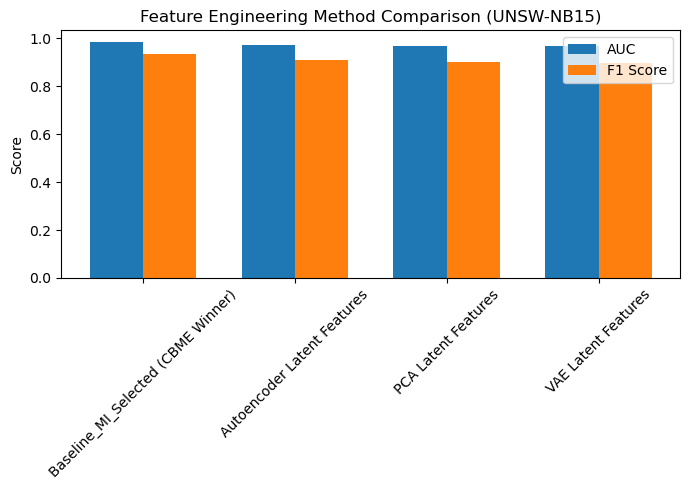

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Filter UNSW results
df = perf_df[perf_df["Dataset"] == "UNSW-NB15"].copy()

x = np.arange(len(df))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, df["AUC"], width, label="AUC")
plt.bar(x + width/2, df["F1"], width, label="F1 Score")

plt.xticks(x, df["Feature_Set"], rotation=45)
plt.ylabel("Score")
plt.title("Feature Engineering Method Comparison (UNSW-NB15)")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/plots/feature_engineering_comparison.png", dpi=300)
plt.show()